## Importing Libraries

In [1]:
#Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Reading Files

In [2]:
#Reading csv files
df1 = pd.read_csv('data/olist_customers_dataset.csv.zip')
df2 = pd.read_csv('data/olist_order_items_dataset.csv.zip')
df3 = pd.read_csv('data/olist_order_payments_dataset.csv.zip')
df4 = pd.read_csv('data/olist_order_reviews_dataset.csv.zip')
df5 = pd.read_csv('data/olist_orders_dataset.csv.zip')
df6 = pd.read_csv('data/olist_products_dataset.csv.zip')
df7 = pd.read_csv('data/olist_sellers_dataset.csv')
df8 = pd.read_csv('data/product_category_name_translation.csv')

In [3]:
#Columns in different dataframes
for name, df in zip(['customers_dataset','order_items_dataset', 'order_payments_dataset', 'order_reviews_dataset', 'orders_dataset.csv', 'products_dataset', 'sellers_dataset', "product_category_name_translation"], [df1, df2, df3, df4, df5, df6, df7, df8]):
    print(f"--- columns from {name} ---")
    display(df.columns)
    print("\n")

--- columns from customers_dataset ---


Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')



--- columns from order_items_dataset ---


Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')



--- columns from order_payments_dataset ---


...

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')



--- columns from sellers_dataset ---


Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')



--- columns from product_category_name_translation ---


Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [4]:
#Displaying different csv files
for name, df in zip(['customers_dataset', 'order_items_dataset', 'order_payments_dataset', 'order_reviews_dataset', 'orders_dataset.csv', 'products_dataset', 'sellers_dataset', "product_category_name_translation"], [df1, df2, df3, df4, df5, df6, df7, df8]):
    print(f"--- Sample from {name} ---")
    display(df.sample(5))
    print("\n")

--- Sample from customers_dataset ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
73225,8fcf47699a97e2603c19102a9412b4b0,45444a613794a79463b02b62ad6fdb44,42738,lauro de freitas,BA
60255,edb3e8d308914f62482ddfbdf7b9cce2,d86389bdf95ef92cf7454e6067f1dd04,11701,praia grande,SP
46493,50bcce86319ecdf2df1edeae7272a38e,bd6e919ea010cdfb03825ac482546540,5606,sao paulo,SP
13790,5ec721f1279b850510ac109a5cad14c4,af116fbccaa2f1d9db020b0625f4db08,95660,tres coroas,RS
31543,62700f8d4a9563f7bf60faf623e866b8,0fa960f8f6215551889f2124f2e3bd70,4602,sao paulo,SP




--- Sample from order_items_dataset ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
43781,637c53efeb8436b5bb339182ab5d03d0,1,7caf32b90e6fbccc6a37ee8633644895,32b8764b4ef628b53608fc34011fcc13,2018-08-24 10:10:16,259.0,76.61
44439,64fd78c83d0cab22a8284559075fbfb9,1,4e43377af2dd03dac8d7b4d0e889559a,5160d23075764e18e07c1f4a87fad743,2017-08-23 19:10:17,85.0,7.85
4653,0a814fddd9db7c515225361a87b607bb,1,cdc4af478fef19f03f1d0353c00271cd,3d871de0142ce09b7081e2b9d1733cb1,2018-04-18 22:31:42,29.9,19.32
13987,1fd9362a40211b8ab54154b0f8f7a657,2,0c2ec8ad337c82681af769354356e4c2,e59e489e2ea74bd409b798b5daf49de3,2017-09-13 02:55:13,99.0,13.71
5769,0cfb04a3e59f3ce319891d208135885b,1,99b89f140f651db441848081814dd1a1,3340ef1913fb70d28420f6ceb685c339,2017-03-09 12:10:25,195.9,19.96




--- Sample from order_payments_dataset ---


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
7644,58af7b4490d18df213fb7c5e7a42ce97,livros_tecnicos,41.0,2063.0,1.0,700.0,27.0,3.0,19.0
20822,249da1970e34871eedb6b6a70e89aec2,market_place,64.0,2112.0,2.0,1600.0,24.0,4.0,17.0
28482,bd421826916d3e1d445cb860cea3c0fb,NaN,NaN,NaN,NaN,250.0,16.0,4.0,11.0
17113,716a15647e7f7cfa2f875d657dae4c03,cool_stuff,41.0,634.0,3.0,625.0,18.0,14.0,16.0
21478,ad0a798e7941f3a5a2fb8139cb62ad78,cama_mesa_banho,55.0,617.0,1.0,600.0,16.0,10.0,16.0




--- Sample from sellers_dataset ---


,seller_id,seller_zip_code_prefix,seller_city,seller_state
908,b1fecf4da1fa2689bccffa0121953643,79107,campo grande,MS
483,c5f7e746b7e6d07def6c0dae9903279b,81350,curitiba,PR
2420,bd4ff04377f974574f7f0bf9d6ce7dde,17370,santa maria da serra,SP
2273,4c03b9dd4c11ee2cb35c96c49efc9420,13232,campo limpo paulista,SP
1793,a2e85714b56b1cb6bb24a9a6e6cad36f,14530,miguelopolis,SP




--- Sample from product_category_name_translation ---


,product_category_name,product_category_name_english
5,esporte_lazer,sports_leisure
65,dvds_blu_ray,dvds_blu_ray
56,eletrodomesticos_2,home_appliances_2
37,agro_industria_e_comercio,agro_industry_and_commerce
54,artigos_de_natal,christmas_supplies


## Merging Files

In [5]:
##Merging all columns of all files(except Geolocation file)
orders_customers = pd.merge(df5, df1, on='customer_id', how='left')
order_items_products = pd.merge(df2, df6, on='product_id', how='left')
order_items_products_sellers = pd.merge(order_items_products, df7, on='seller_id', how='left')
orders_items_products_sellers_customers = pd.merge(orders_customers, order_items_products_sellers, on='order_id', how='left')
merged_df = pd.merge(orders_items_products_sellers_customers, df4, on='order_id', how='left')
merged_df = pd.merge(merged_df, df5, on='order_id', how='left')

merged_df = pd.merge(merged_df, df8, on='product_category_name', how='left')

# Geolocation data not merged

print("Merged Dataset Shape: ", merged_df.shape)
print("Columns\n", merged_df.columns)
display(merged_df.sample(5))


Merged Dataset Shape:  (114092, 43)
Columns
 Index(['order_id', 'customer_id_x', 'order_status_x',
       'order_purchase_timestamp_x', 'order_approved_at_x',
       'order_delivered_carrier_date_x', 'order_delivered_customer_date_x',
       'order_estimated_delivery_date_x', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'customer_id_y',
       'order_status_y', 'order_purchase_timestamp_y', 'order_approved_at_y',
       'order_deli

,order_id,customer_id_x,order_status_x,order_purchase_timestamp_x,order_approved_at_x,order_delivered_carrier_date_x,order_delivered_customer_date_x,order_estimated_delivery_date_x,customer_unique_id,customer_zip_code_prefix,...,review_creation_date,review_answer_timestamp,customer_id_y,order_status_y,order_purchase_timestamp_y,order_approved_at_y,order_delivered_carrier_date_y,order_delivered_customer_date_y,order_estimated_delivery_date_y,product_category_name_english
104792,5bd293c86326611e6604399e535f1b2b,de270dbea5d94e6436d844565b1c52aa,shipped,2018-06-18 21:09:41,2018-06-19 21:18:40,2018-06-20 14:47:00,NaN,2018-07-19 00:00:00,23a25807386b02e977d0e25355066a28,49360,...,2018-07-22 00:00:00,2018-07-30 12:24:09,de270dbea5d94e6436d844565b1c52aa,shipped,2018-06-18 21:09:41,2018-06-19 21:18:40,2018-06-20 14:47:00,NaN,2018-07-19 00:00:00,auto
51899,e23cd9d0832eeac3bc6e9c55cbb64a53,5daf6455918cb226e592f6ad0cde4a6c,delivered,2017-07-09 23:48:00,2017-07-11 04:04:02,2017-07-11 13:42:17,2017-07-12 20:12:08,2017-07-21 00:00:00,eee59c3622420d28e64745623af48741,5207,...,2017-07-13 00:00:00,2017-07-14 00:39:05,5daf6455918cb226e592f6ad0cde4a6c,delivered,2017-07-09 23:48:00,2017-07-11 04:04:02,2017-07-11 13:42:17,2017-07-12 20:12:08,2017-07-21 00:00:00,fashion_bags_accessories
100972,be5435c57df6900352df2542b39a99de,a130282ae152ff07a4c853008884ed9c,delivered,2017-12-08 18:25:45,2017-12-08 18:35:24,2017-12-12 22:19:19,2017-12-19 13:04:12,2018-01-08 00:00:00,cc371e5fbd115ff2543923d1cd2c6ed7,7130,...,2017-12-20 00:00:00,2017-12-20 16:36:21,a130282ae152ff07a4c853008884ed9c,delivered,2017-12-08 18:25:45,2017-12-08 18:35:24,2017-12-12 22:19:19,2017-12-19 13:04:12,2018-01-08 00:00:00,luggage_accessories
109588,adc7395f708cb4b4b9465287b588bb64,470288b06929cb091841666a22e1296e,delivered,2017-06-04 20:33:17,2017-06-04 20:45:14,2017-06-05 12:33:55,2017-06-13 17:56:07,2017-07-04 00:00:00,13ce9e31a65e1643a5d0ebafcaf3c6e5,22610,...,2017-06-14 00:00:00,2017-06-17 02:57:48,470288b06929cb091841666a22e1296e,delivered,2017-06-04 20:33:17,2017-06-04 20:45:14,2017-06-05 12:33:55,2017-06-13 17:56:07,2017-07-04 00:00:00,toys
17635,0412356b9ae3ad8db617e892afb02204,d8c75086006d46bf0e3f33b17a2404b9,delivered,2018-06-19 08:43:13,2018-06-20 02:55:01,2018-06-25 15:01:00,2018-06-29 20:18:33,2018-07-16 00:00:00,ae4a04f0b8b5b2860f4d32b1490314b8,38747,...,2018-06-30 00:00:00,2018-07-01 03:01:16,d8c75086006d46bf0e3f33b17a2404b9,delivered,2018-06-19 08:43:13,2018-06-20 02:55:01,2018-06-25 15:01:00,2018-06-29 20:18:33,2018-07-16 00:00:00,garden_tools


In [6]:
#Merging specific columns of different files
order_data = df5.merge(df2, on='order_id') \
                   .merge(df3, on='order_id') \
                   .merge(df1, on='customer_id') \
                   .merge(df4[['order_id', 'review_score']], on='order_id', how='left') \
                   .merge(df6[['product_id', 'product_category_name']], on='product_id', how='left') \
                   .merge(df8, on='product_category_name', how='left')


# Geolocation data not merged

order_data = order_data.drop('product_category_name', axis=1) #dropping Portuguese product name(keeping English name)

#displaying
display(order_data.shape)
display(order_data.columns)
display(order_data.sample(5))

#order details(id,status,purchase date, approved date, delivery dates,product id, shipping date,price,freight value)
#customer details(id,zip_code,city,state),seller(id,) product etails(id,category_name)
#payement details(payment type,installments,vaue,sequential)

(118307, 24)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'review_score', 'product_category_name_english'],
      dtype='object')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,product_category_name_english
36183,7fae897a23c0c0b24a16aa156a536f91,594f97ee14747a7fe1d623bf200a7587,delivered,2018-01-13 21:22:32,2018-01-16 03:51:13,2018-01-23 20:51:38,2018-01-26 13:42:42,2018-02-02 00:00:00,1,6bbe55cf8f85c87b6eebb775a53402f4,...,1,boleto,1,63.62,5ccaad2cfe356734f866f8e9171274f2,13040,campinas,SP,4.0,tablets_printing_image
29857,cec9f2d01230a5ec8b92b222bdcb3c41,1fbd8147176eca1835aa64b2f0e5e32f,delivered,2017-07-01 00:15:30,2017-07-01 14:43:45,2017-07-07 18:23:14,2017-07-17 20:33:40,2017-08-02 00:00:00,1,967a628ee966c8a0a167ed5efaba52a0,...,1,credit_card,8,354.90,ece666ce869d4ab864a296b4f279525e,89460,canoinhas,SC,3.0,furniture_decor
12768,5026ee6df4dbdda4bd738ab9943204c6,41c26b1d292218ff7bb631e05cebcb31,delivered,2017-08-26 19:08:13,2017-08-26 19:24:06,2017-08-29 18:43:00,2017-09-11 17:55:47,2017-09-25 00:00:00,1,b6a1a729d84991c54d232ed0fb0b8deb,...,1,credit_card,4,403.05,47d1c4416d67d0f7f6335d48eb7d36c5,64300,valenca do piaui,PI,5.0,auto
83072,97826eac2ea69cbcffac7c3358a19138,b164311fb207ff095a8aec678688c763,delivered,2017-10-21 20:19:39,2017-10-21 20:35:23,2017-10-25 22:47:49,2017-11-06 19:55:46,2017-11-29 00:00:00,2,368c6c730842d78016ad823897a372db,...,1,credit_card,3,177.44,798c51ba7cb7ae0428009a93ee51ebb8,68743,castanhal,PA,5.0,garden_tools
56654,6305aec3fc288054e3c30457795f98a8,a8c83ac2daecf7bd93935aba418f8cd2,delivered,2017-10-02 08:32:05,2017-10-02 08:49:20,2017-10-06 16:52:34,2017-10-17 19:41:07,2017-11-23 00:00:00,1,8a1fccc6b1baa3ff391c89b916176091,...,1,credit_card,1,54.14,986d0721d7862ed532a09b74d6fa1dc2,69047,manaus,AM,5.0,toys


## Data Cleaning 

In [7]:
order_data.drop_duplicates(inplace=True,ignore_index=True)
order_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117888 entries, 0 to 117887
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117888 non-null  object 
 1   customer_id                    117888 non-null  object 
 2   order_status                   117888 non-null  object 
 3   order_purchase_timestamp       117888 non-null  object 
 4   order_approved_at              117873 non-null  object 
 5   order_delivered_carrier_date   116636 non-null  object 
 6   order_delivered_customer_date  115308 non-null  object 
 7   order_estimated_delivery_date  117888 non-null  object 
 8   order_item_id                  117888 non-null  int64  
 9   product_id                     117888 non-null  object 
 10  seller_id                      117888 non-null  object 
 11  shipping_limit_date            117888 non-null  object 
 12  price                         

In [8]:
order_data.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1252
order_delivered_customer_date    2580
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
review_score                      978
product_category_name_english    1728
dtype: int64

##### Cleaning datetime columns

In [9]:
#Converting data type of date col from object to datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
]

for col in date_columns:
    order_data[col] = pd.to_datetime(order_data[col], errors='coerce')

order_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117888 entries, 0 to 117887
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117888 non-null  object        
 1   customer_id                    117888 non-null  object        
 2   order_status                   117888 non-null  object        
 3   order_purchase_timestamp       117888 non-null  datetime64[ns]
 4   order_approved_at              117873 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116636 non-null  datetime64[ns]
 6   order_delivered_customer_date  115308 non-null  datetime64[ns]
 7   order_estimated_delivery_date  117888 non-null  datetime64[ns]
 8   order_item_id                  117888 non-null  int64         
 9   product_id                     117888 non-null  object        
 10  seller_id                      117888 non-null  object        
 11  

In [10]:
#Removing time from columns 
order_data['ord_purchase_date']=order_data['order_purchase_timestamp'].dt.date
order_data['ord_approved_date']=order_data['order_approved_at'].dt.date
order_data['ord_carrier_date']=order_data['order_delivered_carrier_date'].dt.date
order_data['ord_delivery_customer_date']=order_data['order_delivered_customer_date'].dt.date
order_data['est_ord_deliver_date']=order_data['order_estimated_delivery_date'].dt.date
order_data['ord_shipping_date']=order_data['shipping_limit_date'].dt.date
order_data.drop(columns=date_columns,inplace=True)

In [11]:
#Converting data type of date col from object to datetime
date_column = [
    'ord_purchase_date',
    'ord_approved_date',
    'ord_carrier_date',
    'ord_delivery_customer_date',
    'est_ord_deliver_date',
    'ord_shipping_date',
]

for col in date_column:
    order_data[col] = pd.to_datetime(order_data[col], errors='coerce')

order_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117888 entries, 0 to 117887
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117888 non-null  object        
 1   customer_id                    117888 non-null  object        
 2   order_status                   117888 non-null  object        
 3   order_item_id                  117888 non-null  int64         
 4   product_id                     117888 non-null  object        
 5   seller_id                      117888 non-null  object        
 6   price                          117888 non-null  float64       
 7   freight_value                  117888 non-null  float64       
 8   payment_sequential             117888 non-null  int64         
 9   payment_type                   117888 non-null  object        
 10  payment_installments           117888 non-null  int64         
 11  

##### EDA

In [12]:
#differentiating col as categorical, numerical, datetime columns
categorical_col = [col for col in order_data.columns if order_data[col].dtype == 'object']
datetime_col = [col for col in order_data.columns if order_data[col].dtype == 'datetime64[ns]']
numerical_col = [col for col in order_data.columns if order_data[col].dtype != 'object' and order_data[col].dtype != 'datetime64[ns]']

In [13]:
order_data[categorical_col].describe()

,order_id,customer_id,order_status,product_id,seller_id,payment_type,customer_unique_id,customer_city,customer_state,product_category_name_english
count,117888,117888,117888,117888,117888,117888,117888,117888,117888,116160
unique,98665,98665,7,32951,3095,4,95419,4110,27,71
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,credit_card,9a736b248f67d166d2fbb006bcb877c3,sao paulo,SP,bed_bath_table
freq,63,63,115309,536,2148,86962,75,18649,49676,11898


##### As unique value in order_id and customer id is same with same frequencies so we  can drop customer_id

In [14]:
order_data.drop(columns='customer_id',inplace=True)
order_data.drop(columns='customer_zip_code_prefix',inplace=True)

In [15]:
order_data[datetime_col].sample(5)

,ord_purchase_date,ord_approved_date,ord_carrier_date,ord_delivery_customer_date,est_ord_deliver_date,ord_shipping_date
23106,2018-03-20,2018-03-20,2018-03-23,2018-04-19,2018-04-09,2018-03-26
92848,2017-11-23,2017-11-23,2017-11-24,2017-12-09,2017-12-13,2017-11-29
75899,2018-03-23,2018-03-23,2018-03-24,2018-04-08,2018-05-03,2018-04-03
11690,2018-02-03,2018-02-03,2018-02-08,2018-02-14,2018-03-01,2018-02-08
24635,2017-06-23,2017-06-23,2017-06-23,2017-06-27,2017-07-13,2017-06-29


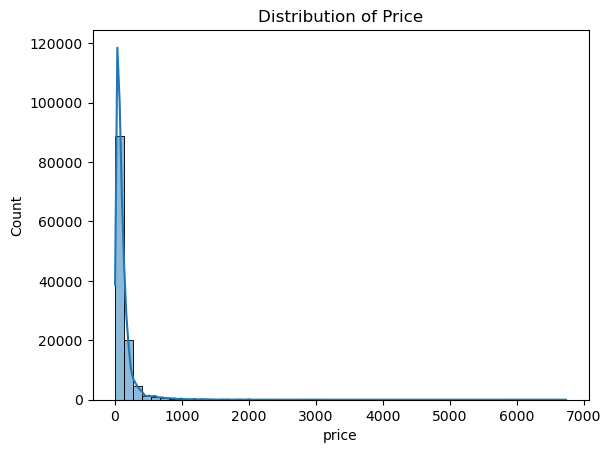

In [16]:
sns.histplot(order_data['price'], bins=50, kde = True)
plt.title('Distribution of Price')
plt.show()

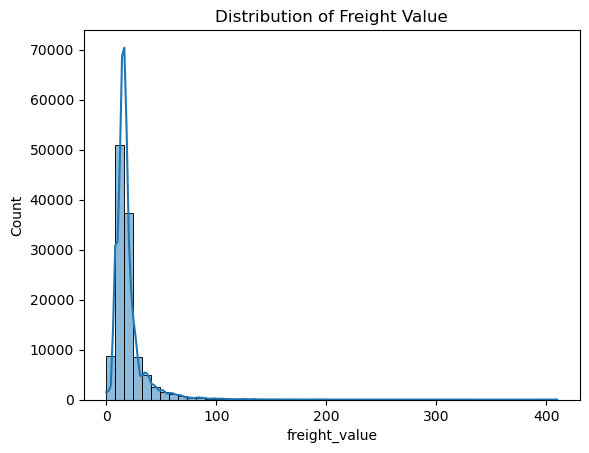

In [17]:
sns.histplot(order_data['freight_value'], bins=50, kde = True)
plt.title('Distribution of Freight Value')
plt.show()

customer_state
SP    49676
RJ    15381
MG    13662
RS     6506
PR     5976
SC     4306
BA     4058
DF     2487
GO     2445
ES     2341
PE     1892
CE     1555
MT     1126
PA     1118
MS      848
MA      846
PB      639
PI      573
RN      570
AL      459
SE      397
TO      339
RO      286
AM      171
AC       95
AP       84
RR       52
Name: count, dtype: int64

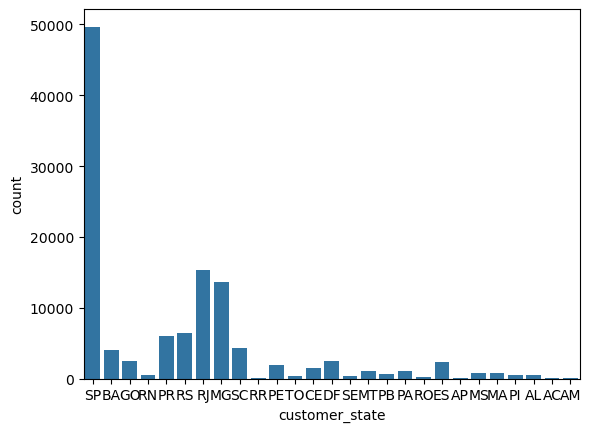

In [18]:
sns.countplot(order_data,x='customer_state')
order_data['customer_state'].value_counts()
#this of no use

In [19]:
#dropping customer state and city
order_data.drop(columns='customer_state',inplace=True)
order_data.drop(columns='customer_city',inplace=True)

<Axes: xlabel='payment_type', ylabel='count'>

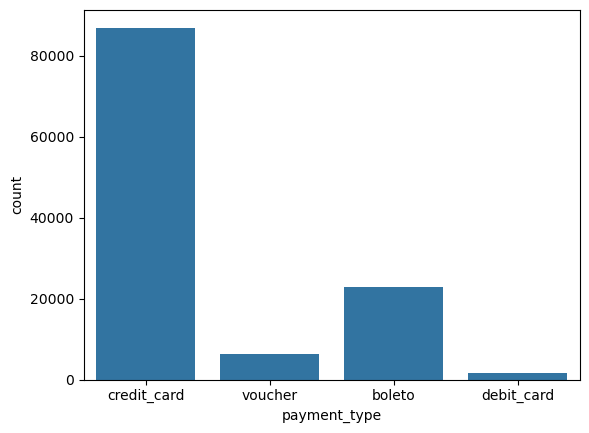

In [20]:
sns.countplot(order_data,x='payment_type')

<Axes: xlabel='review_score', ylabel='count'>

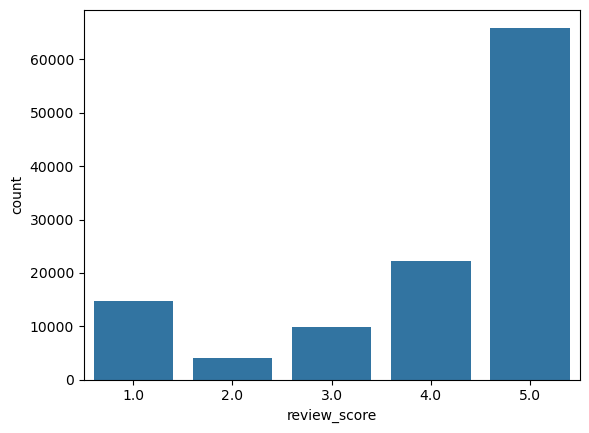

In [21]:
sns.countplot(order_data,x='review_score')

<Axes: ylabel='count'>

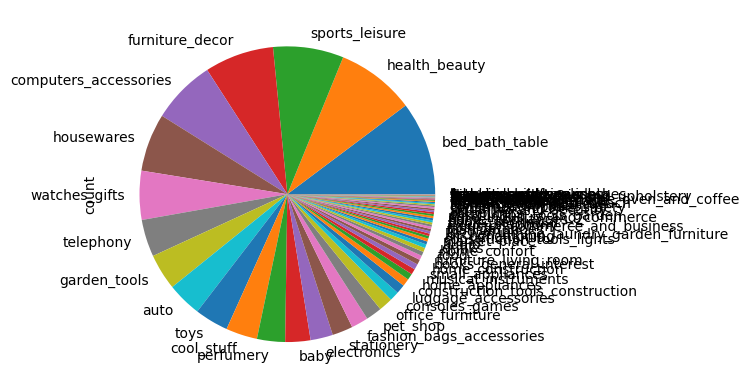

In [22]:
#sns.countplot(order_data,x='product_category_name_english')
order_data['product_category_name_english'].value_counts().plot(kind='pie')
# if we want to use this columns we need to group various products of same type .

#### New dataframe to find CLV

In [23]:
order_data['customer_unique_id'].value_counts()

customer_unique_id
9a736b248f67d166d2fbb006bcb877c3    75
6fbc7cdadbb522125f4b27ae9dee4060    38
f9ae226291893fda10af7965268fb7f6    35
8af7ac63b2efbcbd88e5b11505e8098a    29
569aa12b73b5f7edeaa6f2a01603e381    26
                                    ..
cccd50988ef52de84f8ed4002fb28ab5     1
b632c70b9c2c062dfacbad69e08f6563     1
2dee0e87b84b55e9879355315c11eb03     1
f04534e01ef384f6f11113da312438a8     1
60350aa974b26ff12caad89e55993bd6     1
Name: count, Length: 95419, dtype: int64

In [24]:
a=order_data.groupby('customer_unique_id')['order_id'].count()
b=order_data.groupby('customer_unique_id')['payment_value'].sum()
c=order_data.groupby('customer_unique_id')['price'].sum()
d=order_data.groupby('customer_unique_id')['freight_value'].sum()
e=order_data.groupby('customer_unique_id')['ord_purchase_date'].min()
f=order_data.groupby('customer_unique_id')['ord_purchase_date'].max()



In [25]:
z=pd.merge(a,b, on='customer_unique_id')
z=pd.merge(z,c, on='customer_unique_id')
z=pd.merge(z,d, on='customer_unique_id')
z=pd.merge(z,e, on='customer_unique_id')
z=pd.merge(z,f, on='customer_unique_id')

In [26]:
z.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95419 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             95419 non-null  int64         
 1   payment_value        95419 non-null  float64       
 2   price                95419 non-null  float64       
 3   freight_value        95419 non-null  float64       
 4   ord_purchase_date_x  95419 non-null  datetime64[ns]
 5   ord_purchase_date_y  95419 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(3), int64(1)
memory usage: 5.1+ MB


In [27]:
z.sample(10)

,order_id,payment_value,price,freight_value,ord_purchase_date_x,ord_purchase_date_y
customer_unique_id,,,,,,
f81c042ed0162a51b90372c233b4fbad,1,65.84,55.90,9.94,2017-07-23,2017-07-23
ac96769b758dad3bd572bc5e3fcb8511,1,313.50,299.90,13.60,2017-11-05,2017-11-05
54680839ede02ad16e6886ec2be7deef,1,60.73,45.50,15.23,2018-05-23,2018-05-23
c34e349e96f7ad6ceb0723adb5400f0c,2,473.40,220.64,16.06,2018-07-04,2018-07-04
23262017537d6c2a2b671983cc5b5d81,1,76.17,59.99,16.18,2017-10-25,2017-10-25
a49dd8503d568692a2845ed27a713d92,1,185.61,159.00,26.61,2017-04-07,2017-04-07
d3e37305cc017f3285f738cfecac98f2,1,128.73,109.00,19.73,2018-04-13,2018-04-13
8a0855d5cb93089e677b9a0b601bc03f,1,328.42,259.90,68.52,2017-03-28,2017-03-28
d20c006baf398a938c2b1fbbf9aa9c54,1,165.71,149.90,15.81,2017-11-02,2017-11-02


#### Calculating total time a person is associated with the company

In [28]:
z['number_of_days']=z['ord_purchase_date_y']-z['ord_purchase_date_x']


In [29]:
z.sample(10)

,order_id,payment_value,price,freight_value,ord_purchase_date_x,ord_purchase_date_y,number_of_days
customer_unique_id,,,,,,,
336a8c5ed580bb95103d60b140da906c,1,119.88,104.40,15.48,2018-02-09,2018-02-09,0 days
5818716896e61882c80b6044380c0795,1,40.42,19.90,20.52,2018-04-10,2018-04-10,0 days
861eff4711a542e4b93843c6dd7febb0,1,146.87,124.99,21.88,2017-05-16,2017-05-16,0 days
7713212dfe73f9d229ce336e0e67edc9,1,127.45,99.90,27.55,2018-01-24,2018-01-24,0 days
7a53ba76258617f396248d5d2de031db,1,100.35,79.00,21.35,2017-12-04,2017-12-04,0 days
2a7b441f70445524d878a31370acf548,1,94.44,76.99,17.45,2018-03-28,2018-03-28,0 days
490d506e89c13c85d52896cf4364ae76,1,167.39,149.90,17.49,2018-03-03,2018-03-03,0 days
ce0c3f9cf5bab2a59415a5216940c9f6,1,148.98,129.97,19.01,2018-07-02,2018-07-02,0 days
a49dd8503d568692a2845ed27a713d92,1,185.61,159.00,26.61,2017-04-07,2017-04-07,0 days


In [30]:
z['number_of_days'].value_counts()

number_of_days
0 days      93334
1 days         44
2 days         37
6 days         30
7 days         27
            ...  
382 days        1
360 days        1
518 days        1
433 days        1
322 days        1
Name: count, Length: 424, dtype: int64